# Clustering countries by sex × age employment trajectories

[Kaggle dataset: lucalullo/global-employment-unemployment-rates-1991-2025](https://www.kaggle.com/datasets/lucalullo/global-employment-unemployment-rates-1991-2025)

Each country is a row. **Features** summarize **employment** (`occupazione`) time series for every `sex × age` slice: long-run **mean**, **std**, and **OLS slope vs year** (same idea as a trajectory model). That encodes **level, volatility, and trend** per demographic band while keeping years comparable across countries.

**KMeans** is fit on these features only (not on raw unemployment). We then **describe** clusters with unemployment and employment **trajectories** and **country lists**. Clusters are exploratory, not causal labels.

## Setup & load

In [1]:
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

PRISM = list(px.colors.qualitative.Prism)
px.defaults.color_discrete_sequence = PRISM
px.defaults.color_continuous_scale = [[i / max(len(PRISM) - 1, 1), c] for i, c in enumerate(PRISM)]
px.defaults.template = "plotly_white"

_IS_KAGGLE = bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE")) or Path("/kaggle").exists()
if _IS_KAGGLE:
    pio.renderers.default = "iframe"


def show_plotly(fig):
    fig.update_layout(paper_bgcolor="white", plot_bgcolor="white", colorway=PRISM)
    if os.environ.get("PLOTLY_FORCE_HTML", "").lower() in ("1", "true", "yes"):
        display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))
    elif _IS_KAGGLE:
        fig.show()
    else:
        display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))


def resolve_data_dir() -> Path:
    explicit = Path("/kaggle/input/global-employment-unemployment-rates-1991-2025")
    if explicit.exists():
        return explicit
    base = Path("/kaggle/input")
    if base.exists():
        for p in base.rglob("occupazione.csv"):
            return p.parent
    local = Path("data")
    assert (local / "occupazione.csv").exists() and (local / "disoccupazione.csv").exists(), (
        f"Expected occupazione.csv and disoccupazione.csv under {local.resolve()} — run `make download`"
    )
    return local


def load_employment_frames(data_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    xlsx = sorted(data_dir.glob("*.xlsx")) + sorted(data_dir.glob("*.xls"))
    if xlsx:
        path = xlsx[0]
        emp = pd.read_excel(path, sheet_name="occupazione")
        unemp = pd.read_excel(path, sheet_name="disoccupazione")
    else:
        ocp, disc = data_dir / "occupazione.csv", data_dir / "disoccupazione.csv"
        assert ocp.exists() and disc.exists(), f"Missing CSVs under {data_dir}"
        emp = pd.read_csv(ocp)
        unemp = pd.read_csv(disc)
    for df in (emp, unemp):
        assert set(df.columns) >= {"iso_code", "country", "sex", "age", "year", "obs_value"}
    return emp, unemp


DATA_DIR = resolve_data_dir()
print(f"DATA_DIR = {DATA_DIR}")
df_emp, df_unemp = load_employment_frames(DATA_DIR)


DATA_DIR = data


## Feature matrix: employment, every sex × age, time summaries

For each `iso_code` and each `(sex, age)` among `Female` / `Male` / `Total` and `15-24` / `15+` / `25+`, we take the national employment-rate series over years and compute **mean**, **std**, and **slope** (linear trend). Countries missing too many slice-level features are dropped; remaining NaNs are filled with the **column median** so all countries share the same feature space.

**Clustering uses employment features only.** Unemployment is used afterward for interpretation.

In [2]:
STRAT_SEX = ["Female", "Male", "Total"]
STRAT_AGE = ["15-24", "15+", "25+"]


def feat_col(stat: str, sex: str, age: str) -> str:
    safe = age.replace("+", "plus").replace("-", "_")
    return f"emp_{stat}_{sex}_{safe}"


def trajectory_slope(xs: np.ndarray, ys: np.ndarray) -> float:
    m = np.isfinite(xs) & np.isfinite(ys)
    if m.sum() < 2:
        return 0.0
    return float(np.polyfit(xs[m], ys[m], 1)[0])


def employment_stratified_features(df_emp: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for iso, g in df_emp.groupby("iso_code"):
        row: dict = {"iso_code": iso}
        for sex in STRAT_SEX:
            for age in STRAT_AGE:
                sg = g[(g["sex"] == sex) & (g["age"] == age)].sort_values("year")
                c_mean = feat_col("mean", sex, age)
                c_std = feat_col("std", sex, age)
                c_sl = feat_col("slope", sex, age)
                if len(sg) < 5:
                    row[c_mean] = np.nan
                    row[c_std] = np.nan
                    row[c_sl] = np.nan
                    continue
                ys = sg["obs_value"].to_numpy(dtype=float)
                xs = sg["year"].to_numpy(dtype=float)
                row[c_mean] = float(np.nanmean(ys))
                row[c_std] = float(np.nanstd(ys, ddof=1)) if len(ys) > 1 else 0.0
                row[c_sl] = trajectory_slope(xs, ys)
        rows.append(row)
    out = pd.DataFrame(rows).set_index("iso_code")
    return out


feat = employment_stratified_features(df_emp)
country_map = df_emp.drop_duplicates("iso_code").set_index("iso_code")["country"]

min_frac = 0.82
thresh = int(np.ceil(min_frac * feat.shape[1]))
row_ok = feat.notna().sum(axis=1) >= thresh
dropped = int((~row_ok).sum())
feat_f = feat.loc[row_ok].copy()
print(f"Countries kept: {len(feat_f)} (dropped {dropped} with < {min_frac:.0%} non-null slice-features)")

col_med = feat_f.median(axis=0, skipna=True)
n_missing_before = feat_f.isna().sum().sum()
feat_f = feat_f.fillna(col_med)
print(f"Slice-feature cells imputed (column median): {int(n_missing_before)}")

feature_names = list(feat_f.columns)
X = feat_f.to_numpy(dtype=float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
iso_list = feat_f.index.tolist()
print("Employment-only features:", len(feature_names), "| samples:", X_scaled.shape[0])

Countries kept: 183 (dropped 0 with < 82% non-null slice-features)
Slice-feature cells imputed (column median): 0
Employment-only features: 27 | samples: 183


## KMeans: elbow and silhouette (k = 3 … 8)

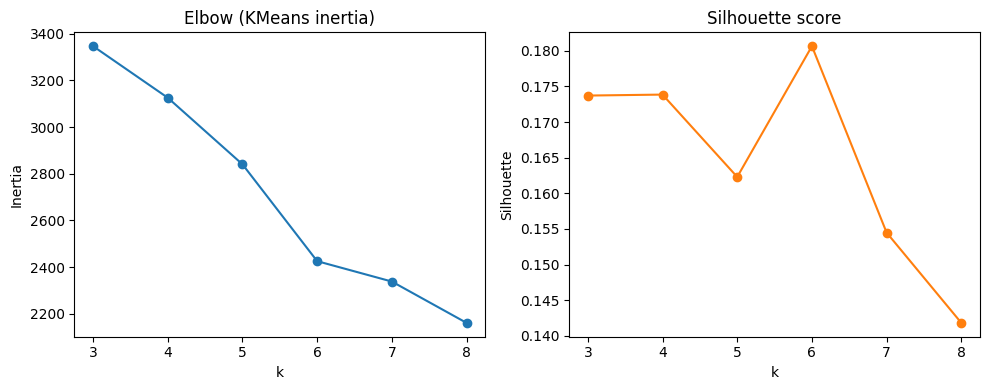

Pick k with max silhouette in grid: k = 6


In [3]:
K_MIN, K_MAX = 3, 8
ks = list(range(K_MIN, K_MAX + 1))
inertias = []
silhouettes = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = (
        silhouette_score(X_scaled, labels)
        if k >= 2 and len(np.unique(labels)) > 1
        else np.nan
    )
    silhouettes.append(sil)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(ks, inertias, marker="o")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow (KMeans inertia)")
ax[1].plot(ks, silhouettes, marker="o", color="C1")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
ax[1].set_title("Silhouette score")
plt.tight_layout()
plt.show()

best_k = int(ks[int(np.nanargmax(silhouettes))])
print(f"Pick k with max silhouette in grid: k = {best_k}")
K_STAR = best_k

## PCA 2D embedding + cluster assignment

In [4]:
km_final = KMeans(n_clusters=K_STAR, random_state=42, n_init="auto")
cluster_labels = km_final.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(X_scaled)
pc_df = pd.DataFrame(
    {
        "PC1": XY[:, 0],
        "PC2": XY[:, 1],
        "cluster": cluster_labels.astype(str),
        "iso_code": iso_list,
        "country": [country_map.get(i, i) for i in iso_list],
    }
)
fig = px.scatter(
    pc_df,
    x="PC1",
    y="PC2",
    color="cluster",
    hover_data=["country", "iso_code"],
    title=f"PCA of employment (sex×age trajectory) features — KMeans k={K_STAR}",
)
show_plotly(fig)
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.30343387 0.26656761]


## Country membership by cluster

Sorted country names per cluster (from the filtered sample used for KMeans).

In [5]:
members = pd.DataFrame(
    {"iso_code": iso_list, "cluster": cluster_labels, "country": [country_map.get(i, i) for i in iso_list]}
)
for cl in sorted(members["cluster"].unique()):
    sub = members[members["cluster"] == cl].sort_values("country")
    print(f"\n--- Cluster {cl} (n={len(sub)}) ---")
    print(", ".join(sub["country"].tolist()))

display(members.groupby("cluster").size().rename("n_countries").to_frame())


--- Cluster 0 (n=39) ---
Afghanistan, Albania, Armenia, Brazil, Brunei Darussalam, Cabo Verde, Congo, Democratic Republic of the, Costa Rica, Cyprus, Czechia, Estonia, Eswatini, Fiji, Greece, Guyana, Haiti, Honduras, Hong Kong, China, India, Iran (Islamic Republic of), Jamaica, Lithuania, Mauritius, Morocco, Portugal, Russian Federation, Rwanda, Samoa, Senegal, Serbia, Sierra Leone, Slovakia, South Africa, Sudan, Taiwan, China, Tonga, Turkmenistan, Türkiye, Venezuela (Bolivarian Republic of)

--- Cluster 1 (n=49) ---
Angola, Australia, Austria, Bahamas, Bahrain, Bangladesh, Benin, Bolivia (Plurinational State of), Cambodia, Canada, Central African Republic, Colombia, Côte d'Ivoire, Denmark, Ecuador, El Salvador, Eritrea, Guatemala, Guinea-Bissau, Iceland, Indonesia, Japan, Kazakhstan, Korea (the Democratic People's Republic of), Kuwait, Lao People's Democratic Republic, Liberia, Madagascar, Mali, Mexico, Netherlands, Niger, Nigeria, Norway, Paraguay, Philippines, Qatar, Solomon Island

,n_countries
cluster,
0,39
1,49
2,20
3,3
4,38
5,34


## Mean trajectories by cluster (employment vs unemployment, stratified)

For each cluster, **unweighted mean** of national rates by year. Facets show several `sex × age` slices so you can see whether clusters differ in youth gaps or gendered patterns — **after** grouping on employment-trajectory features.

In [6]:
clusters_df = pd.DataFrame({"iso_code": iso_list, "cluster": cluster_labels})

SLICES = [
    ("Total", "15+"),
    ("Male", "15-24"),
    ("Female", "15-24"),
    ("Male", "25+"),
    ("Female", "25+"),
]


def slice_cluster_means(dfi: pd.DataFrame, metric_label: str) -> pd.DataFrame:
    chunks = []
    for sex, age in SLICES:
        sub = dfi[(dfi["sex"] == sex) & (dfi["age"] == age)].merge(clusters_df, on="iso_code", how="inner")
        g = sub.groupby(["cluster", "year"], as_index=False)["obs_value"].mean()
        g["slice"] = f"{sex} / {age}"
        g["metric"] = metric_label
        chunks.append(g)
    return pd.concat(chunks, ignore_index=True)


emp_long = slice_cluster_means(df_emp, "Employment")
un_long = slice_cluster_means(df_unemp, "Unemployment")
emp_long["cluster_str"] = emp_long["cluster"].astype(str)
un_long["cluster_str"] = un_long["cluster"].astype(str)

fig = px.line(
    emp_long,
    x="year",
    y="obs_value",
    color="cluster_str",
    facet_row="slice",
    markers=False,
    title=f"Mean employment rate by cluster — k={K_STAR}",
    category_orders={"slice": [f"{s} / {a}" for s, a in SLICES]},
)
fig.update_layout(height=220 * len(SLICES))
fig.update_yaxes(title_text="Rate (%)", matches=None)
show_plotly(fig)

fig = px.line(
    un_long,
    x="year",
    y="obs_value",
    color="cluster_str",
    facet_row="slice",
    markers=False,
    title=f"Mean unemployment rate by cluster — k={K_STAR} (descriptive; not used to fit KMeans)",
    category_orders={"slice": [f"{s} / {a}" for s, a in SLICES]},
)
fig.update_layout(height=220 * len(SLICES))
fig.update_yaxes(title_text="Rate (%)", matches=None)
show_plotly(fig)

## Overall unemployment rate by cluster

**Headline (chart below):** for each country, mean unemployment on **Total / 15+** across all years; each cluster’s bar is the **unweighted mean** of those country means (one vote per country). The table also reports a **pooled** mean where every `(year × sex × age)` row counts equally—useful for comparison but sensitive to how much data each country has per slice.

In [ ]:
# Country-level headline: long-run mean unemployment (Total 15+) per country, then mean by cluster
u_head = df_unemp[(df_unemp["sex"] == "Total") & (df_unemp["age"] == "15+")].merge(
    clusters_df, on="iso_code", how="inner"
)
country_unemp_headline = (
    u_head.groupby(["iso_code", "cluster"], as_index=False)["obs_value"]
    .mean()
    .rename(columns={"obs_value": "country_mean_unemp_pct"})
)
overall_by_cluster = (
    country_unemp_headline.groupby("cluster", as_index=False)
    .agg(
        n_countries=("iso_code", "count"),
        unemp_mean_of_country_means=("country_mean_unemp_pct", "mean"),
        unemp_std_across_countries=("country_mean_unemp_pct", "std"),
    )
    .sort_values("cluster")
)

# Pooled: every (year × sex × age) row weighted equally
pooled = (
    df_unemp.merge(clusters_df, on="iso_code", how="inner")
    .groupby("cluster", as_index=False)["obs_value"]
    .mean()
    .rename(columns={"obs_value": "unemp_pooled_all_rows_pct"})
)
overall_by_cluster = overall_by_cluster.merge(pooled, on="cluster", how="left")
overall_by_cluster["cluster_str"] = overall_by_cluster["cluster"].astype(str)

display(overall_by_cluster.round(2))

fig = px.bar(
    overall_by_cluster,
    x="cluster_str",
    y="unemp_mean_of_country_means",
    title=f"Overall unemployment by cluster (mean of country means, Total 15+) — k={K_STAR}",
    labels={
        "cluster_str": "Cluster",
        "unemp_mean_of_country_means": "Unemployment (%)",
    },
)
fig.update_traces(texttemplate="%{y:.1f}%", textposition="outside")
fig.update_layout(yaxis_title="Unemployment (%)", showlegend=False, uniformtext_minsize=8, uniformtext_mode="hide")
show_plotly(fig)

## Cluster × demographic slice (latest year snapshot)

Mean **employment** in the latest data year, by cluster and `sex / age`, averaging countries in the cluster. This compresses the time dimension into one readable table while staying aligned with the stratification dimensions.

In [7]:
LY = int(df_emp["year"].max())
snap = df_emp[df_emp["year"] == LY].merge(clusters_df, on="iso_code", how="inner")
snap["slice"] = snap["sex"].astype(str) + " / " + snap["age"].astype(str)
heat = snap.groupby(["cluster", "slice"], as_index=False)["obs_value"].mean()
mat = heat.pivot(index="cluster", columns="slice", values="obs_value")
# column order similar to SLICES + Total combinations
col_order = [f"{s} / {a}" for s in STRAT_SEX for a in STRAT_AGE]
col_order = [c for c in col_order if c in mat.columns]
mat = mat[col_order]

fig = px.imshow(
    mat,
    labels=dict(x="Sex / age", y="Cluster", color="Employment %"),
    title=f"Mean employment by cluster and slice — year {LY}",
    aspect="auto",
    color_continuous_scale=px.colors.sequential.Blues,
    height=120 + 40 * len(mat.index),
)
show_plotly(fig)

## Interpretation (qualitative)

- **Level vs trend**: clusters separate countries whose **demographic employment slices** sit at different averages or drift differently over time (slopes in the feature block).
- **Youth / gender in post-hoc plots**: if facets for `15-24` or `Female` diverge across clusters, the grouping is picking up **multi-band** structure, not only `Total / 15+`.
- **Unemployment lines** are **not** inputs to KMeans here; they are a **sanity check** that employment-based groups differ on realized unemployment paths.

These names remain **descriptive**; policy inference needs theory and identification outside this notebook.